# 04 — Analyse Régionale par CARSAT

Classement, tendances et clustering des 17 caisses régionales + 4 caisses DOM.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from src.visualize import plot_carsat_map, save_fig
%matplotlib inline

CARSATS = ['bordeaux','clermont_ferrand','dijon','lille','limoges','lyon',
           'marseille','montpellier','nancy','nantes','orleans','paris',
           'rennes','rouen','strasbourg','toulouse',
           'guadeloupe','guyane','martinique','la_reunion']

## 1. Effectifs retraités au 31/12 — Classement des CARSAT (dernière année disponible)

In [2]:
df_wide = pd.read_parquet('../data/processed/nombre-de-retraites-par-carsat-au-31-decembre.parquet')
df_wide['annees'] = pd.to_numeric(df_wide['annees'], errors='coerce')
df_wide = df_wide.dropna(subset=['annees']).sort_values('annees')

# Passage en format long
df_long = df_wide.melt(id_vars='annees', value_vars=CARSATS,
                        var_name='carsat', value_name='effectif')

# Dernière année disponible, sans national
derniere = int(df_wide['annees'].max())
df_last = df_long[df_long['annees'] == derniere].sort_values('effectif', ascending=False)

fig = plot_carsat_map(df_last, region_col='carsat', value_col='effectif',
                      title=f'Retraités au 31/12 {derniere} par CARSAT')
fig.show()

## 2. Évolution des 5 plus grandes CARSAT

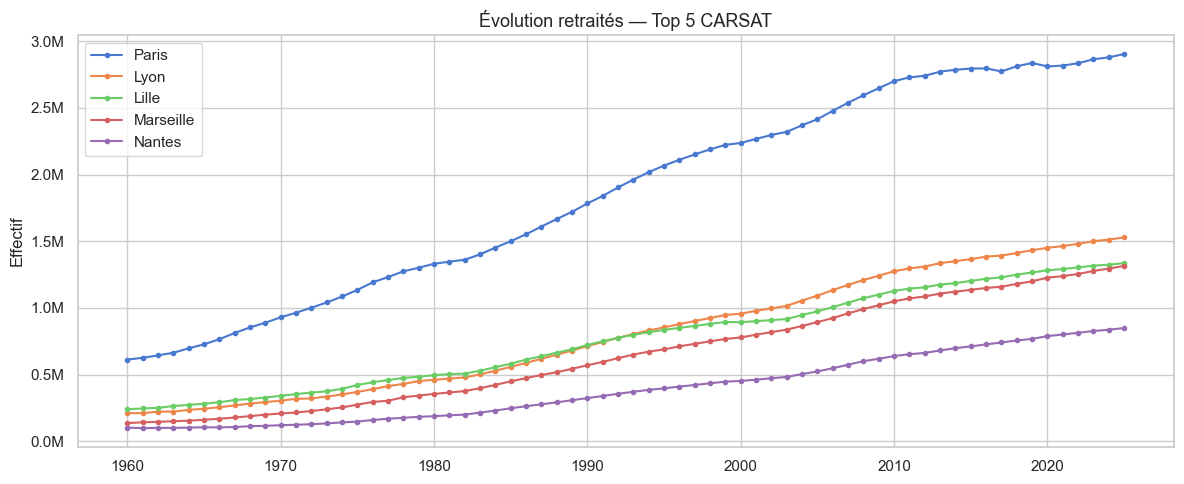

In [3]:
top5 = df_last.nlargest(5, 'effectif')['carsat'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
for carsat in top5:
    s = df_long[df_long['carsat'] == carsat].set_index('annees')['effectif'].sort_index()
    ax.plot(s.index, s.values, label=carsat.replace('_', ' ').title(), marker='o', markersize=3)
ax.set_title('Évolution retraités — Top 5 CARSAT', fontsize=13)
ax.set_ylabel('Effectif')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
save_fig(fig, 'top5_carsat_evolution')
plt.show()

## 3. Attributions annuelles par CARSAT (dataset dédié)

In [4]:
df_attr = pd.read_parquet('../data/processed/attribution-de-lannee-par-region-debitrice.parquet')
df_attr['annees'] = pd.to_numeric(df_attr['annees'], errors='coerce')
df_attr = df_attr.dropna(subset=['annees'])

# Dernière année
derniere_attr = int(df_attr['annees'].max())
df_attr_last = (df_attr[df_attr['annees'] == derniere_attr]
                .sort_values('effectif', ascending=False)
                .rename(columns={'carsat': 'carsat', 'effectif': 'attributions'}))

fig = plot_carsat_map(df_attr_last, region_col='carsat', value_col='attributions',
                      title=f'Attributions {derniere_attr} par CARSAT')
fig.show()
print(f'Total attributions {derniere_attr} : {df_attr_last["attributions"].sum():,.0f}')

Total attributions 2025 : 949,413


## 4. Clustering K-Means des CARSAT (profil démographique)

In [5]:
# Features : effectif dernière année, croissance 10 ans, taux de croissance
annee_ref = derniere - 10
df_ref = df_long[df_long['annees'] == annee_ref][['carsat', 'effectif']].rename(columns={'effectif': 'eff_ref'})
df_features = df_last[['carsat', 'effectif']].merge(df_ref, on='carsat', how='left')
df_features['croissance_abs'] = df_features['effectif'] - df_features['eff_ref']
df_features['croissance_pct'] = ((df_features['effectif'] / df_features['eff_ref']) - 1) * 100
df_features = df_features.dropna()

X = StandardScaler().fit_transform(df_features[['effectif', 'croissance_abs', 'croissance_pct']])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_features['cluster'] = kmeans.fit_predict(X)

print('Clusters K-Means (3 groupes) :')
for c in sorted(df_features['cluster'].unique()):
    membres = df_features[df_features['cluster'] == c]['carsat'].str.replace('_',' ').str.title().tolist()
    print(f'  Cluster {c} : {", ".join(membres)}')

print('\nMoyennes par cluster :')
print(df_features.groupby('cluster')[['effectif', 'croissance_abs', 'croissance_pct']]
      .mean().round(1).to_string())

Clusters K-Means (3 groupes) :
  Cluster 0 : Paris, Lyon, Lille, Marseille
  Cluster 1 : Nantes, Bordeaux, Rouen, Strasbourg, Rennes, Dijon, Toulouse, Orleans, Montpellier, Nancy, Limoges, Clermont Ferrand
  Cluster 2 : La Reunion, Guadeloupe, Martinique, Guyane

Moyennes par cluster :
          effectif  croissance_abs  croissance_pct
cluster                                           
0        1771461.5        146324.0            10.7
1         683119.8         87221.1            14.6
2          71041.8         20167.2            45.3


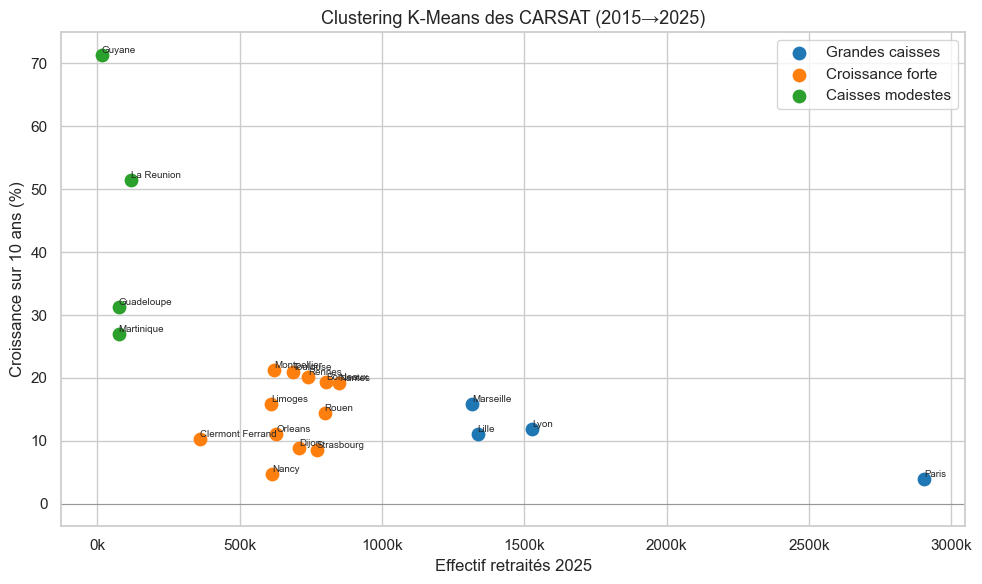

In [6]:
# Visualisation scatter : taille vs croissance
colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}
labels_cluster = {0: 'Grandes caisses', 1: 'Croissance forte', 2: 'Caisses modestes'}

fig, ax = plt.subplots(figsize=(10, 6))
for c, grp in df_features.groupby('cluster'):
    ax.scatter(grp['effectif'], grp['croissance_pct'],
               color=colors[c], label=labels_cluster[c], s=80, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row['carsat'].replace('_',' ').title(),
                    (row['effectif'], row['croissance_pct']),
                    fontsize=7, ha='left', va='bottom')

ax.set_xlabel(f'Effectif retraités {derniere}')
ax.set_ylabel(f'Croissance sur 10 ans (%)')
ax.set_title(f'Clustering K-Means des CARSAT ({annee_ref}→{derniere})', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.axhline(0, color='gray', linewidth=0.5)
ax.legend()
plt.tight_layout()
save_fig(fig, 'clustering_carsat')
plt.show()

## 5. Tendance par CARSAT — taux de croissance annuel moyen

C:\Users\!amolteni\AppData\Local\Temp\ipykernel_11968\2180617958.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  premiere = df_first.groupby('carsat').apply(lambda g: g.nsmallest(1, 'annees')).reset_index(drop=True)


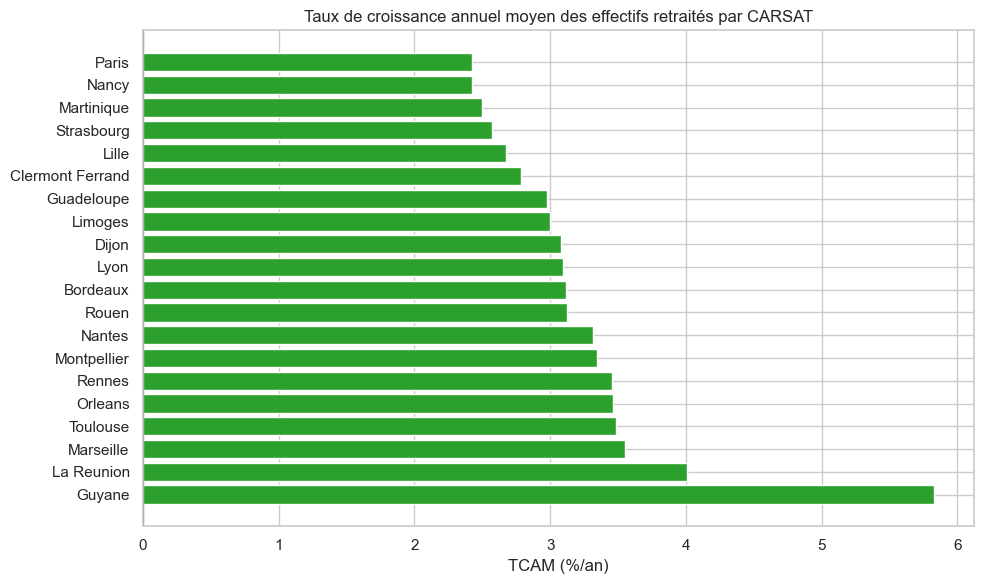

In [7]:
# TCAM sur l'ensemble de la période disponible
df_first = df_long.dropna(subset=['effectif'])
df_first = df_first[df_first['effectif'] > 0]
premiere = df_first.groupby('carsat').apply(lambda g: g.nsmallest(1, 'annees')).reset_index(drop=True)
derniere_df = df_long[df_long['annees'] == derniere][['carsat', 'effectif', 'annees']]

df_tcam = premiere[['carsat', 'effectif', 'annees']].merge(
    derniere_df, on='carsat', suffixes=('_debut', '_fin')
)
df_tcam['nb_ans'] = df_tcam['annees_fin'] - df_tcam['annees_debut']
df_tcam['tcam'] = ((df_tcam['effectif_fin'] / df_tcam['effectif_debut']) ** (1 / df_tcam['nb_ans']) - 1) * 100
df_tcam = df_tcam.sort_values('tcam', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#2ca02c' if v >= 0 else '#d62728' for v in df_tcam['tcam']]
ax.barh(df_tcam['carsat'].str.replace('_',' ').str.title(), df_tcam['tcam'], color=colors_bar)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('TCAM (%/an)')
ax.set_title('Taux de croissance annuel moyen des effectifs retraités par CARSAT', fontsize=12)
plt.tight_layout()
save_fig(fig, 'tcam_carsat')
plt.show()